# SMD 3-Entity Synthetic Anomaly Gallery

Notebook này lấy window thật từ 3 entity SMD benchmark: `machine-1-6`, `machine-3-4`, `machine-3-9`.

Output mặc định là gallery dọc gồm đủ 11 synthetic anomaly family. Mỗi family có 1 clean reference plot và 1 anomaly plot, tổng cộng 22 plot.

Mỗi lần chạy cell chính mà không đặt `FIXED_SEED`, notebook sẽ chọn window khác. Nếu cần tái lập đúng một hình, đặt `FIXED_SEED = <seed trong summary>`.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.append(str(Path.cwd().parent))  # add parent dir into the system PATH
sys.path = list(
    set(sys.path)
)  # resolve duplications if the parent dir has been added before then

import scripts.compare_synthetic_profiles as synthetic_profile_script

# Reload keeps this notebook aligned with the latest script code. ₍^. .^₎⟆
synthetic_profile_script = importlib.reload(synthetic_profile_script)
run_comparison = synthetic_profile_script.run_comparison


class Args:
    experiment_config = None
    legacy_profile = "../configs/protocol/synthetic_redlamp12_legacy_window20.yaml"
    visible_profile = "../configs/protocol/synthetic_redlamp12_visible_window20.yaml"
    output_dir = "../outputs/synthetic_profile_comparison_notebook"
    use_smd_entities = True
    split = "train"
    plot_mode = "full_taxonomy"
    seed = None


# Set FIXED_SEED to an integer if anh muốn tái lập đúng một window.
# Keep it as None if anh muốn mỗi lần Run là một window khác.
FIXED_SEED = None

[DATA] Resolved SMD dataset root | input_root=data/ServerMachineDataset, configured_root_dir=data/ServerMachineDataset, resolved_root=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset, used_environment_override=False
[DATA] Resolved SMD root directory for loader builder | resolved_root_dir=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset
[DATA] Building SMD dataset bundle | resolved_root_dir=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset, window_size=20, train_stride=1, val_stride=20, test_stride=20, batch_size=1
[DATA] Parsing SMD split files | root_dir=/Users/conquerormi

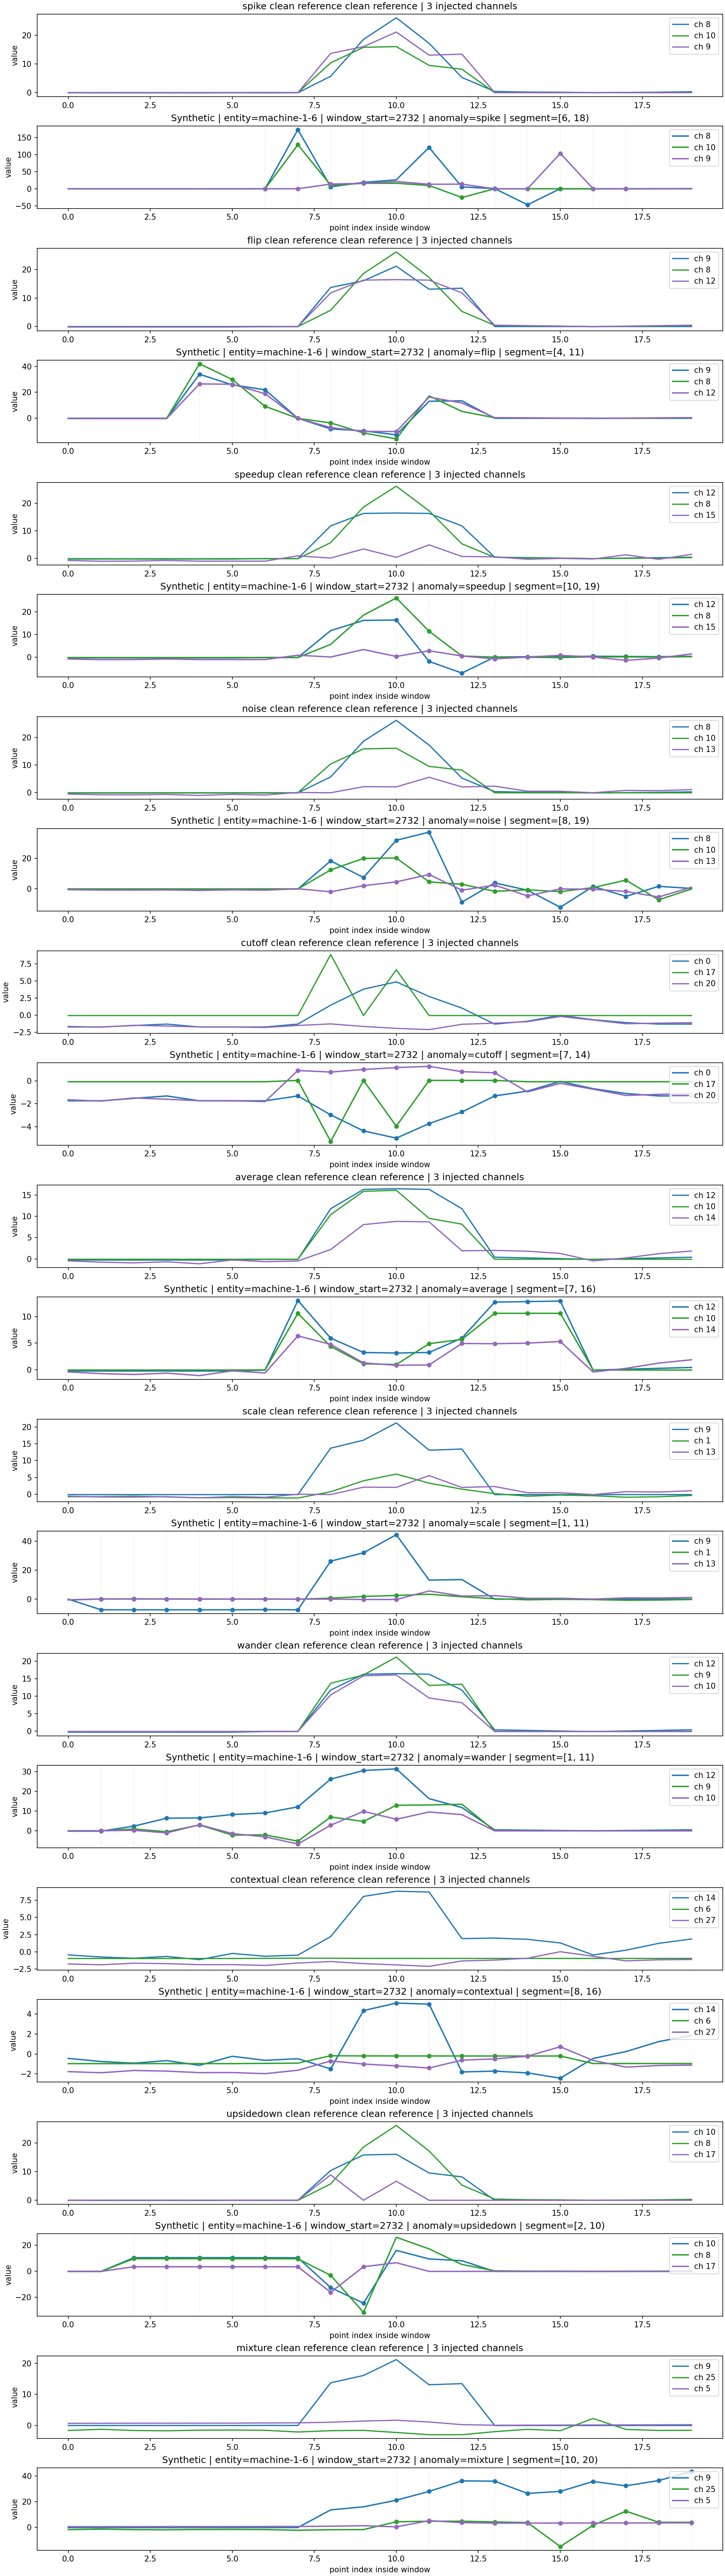

In [6]:
# Refresh once more in the run cell, so rerunning this cell sees new script edits. ( ˶˘ ³˘)♡
synthetic_profile_script = importlib.reload(synthetic_profile_script)
run_comparison = synthetic_profile_script.run_comparison

args = Args()
args.seed = FIXED_SEED

REPO_ROOT = Path.cwd().parent
summary = run_comparison(args)
image_path = (
    REPO_ROOT / args.output_dir / "synthetic_profile_comparison_first_sample.png"
)

print("source:", summary["source"])
print("split:", summary["split"])
print("plot_mode:", summary["plot_mode"])
print("profile_name:", summary.get("profile_name"))
print("base_visualization_seed:", summary["base_visualization_seed"])
print("families:", [item["family_name"] for item in summary["families"]])

display(Image(filename=str(image_path)))